In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

URL = Path("../data/california_housing.csv")
def load_housing_data(URL):
    return pd.read_csv(URL)

In [5]:
# Load the housing data
housing_data = load_housing_data(URL)

In [6]:
# Split the data
X = housing_data.drop("median_house_value",axis=1)
y = housing_data["median_house_value"]

housing_data['rooms_per_house'] = housing_data['total_rooms'] / housing_data['households']
housing_data['bedrooms_per_house'] = housing_data['total_bedrooms'] / housing_data['households']
housing_data['people_per_house'] = housing_data['total_rooms'] / housing_data['households']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>],
       [<Axes: title={'center': 'rooms_per_house'}>,
        <Axes: title={'center': 'bedrooms_per_house'}>,
        <Axes: title={'center': 'people_per_house'}>]], dtype=object)

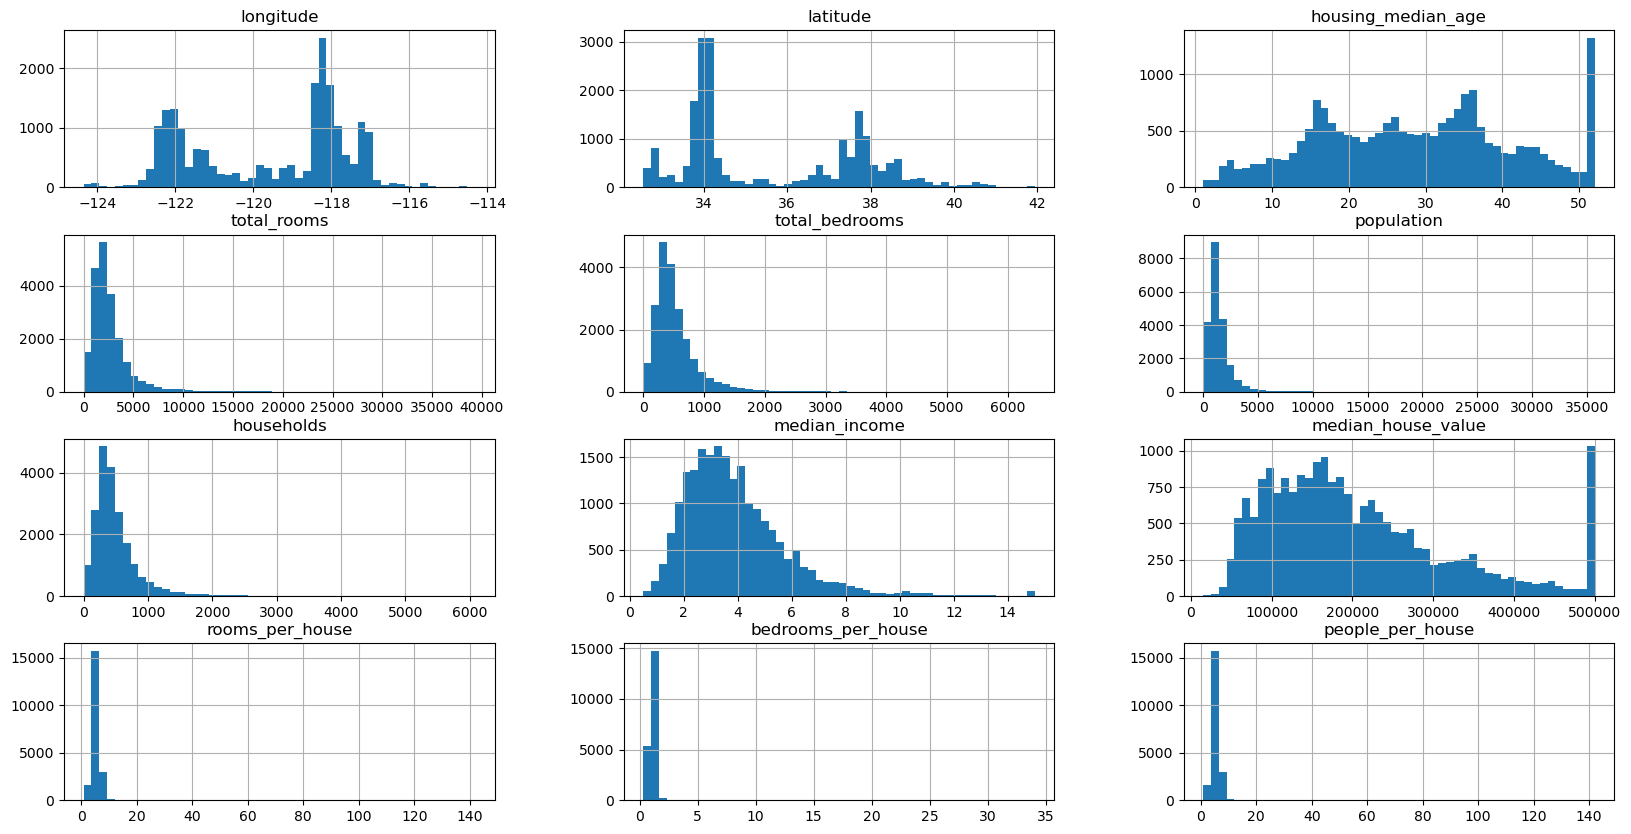

In [7]:
# Insights from data
housing_data.hist(bins=50,figsize=(20,10))


In [9]:
from sklearn.base import BaseEstimator, TransformerMixin
rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6
class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room = True): # no *args or **kargs
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self, X, y=None):
        return self # nothing else to do
    def transform(self, X, y=None):
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household,
            bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)

In [11]:
# Create a pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
num_pipeline = Pipeline([
('imputer', SimpleImputer(strategy="median")),
('attribs_adder', CombinedAttributesAdder()),
('std_scaler', StandardScaler()),
])


In [ ]:
# feature scale and feature engineering
num_attribs = list(X_train.drop("ocean_proximity",axis=1))
cat_attribs = ["ocean_proximity"]
full_pipeline = ColumnTransformer([
("num", num_pipeline, num_attribs),
("cat", OneHotEncoder(), cat_attribs),
])
X_training_data = full_pipeline.fit_transform(X_train)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('attribs_adder',
                                                  CombinedAttributesAdder()),
                                                 ('std_scaler',
                                                  StandardScaler())]),
                                 ['longitude', 'latitude', 'housing_median_age',
                                  'total_rooms', 'total_bedrooms', 'population',
                                  'households', 'median_income']),
                                ('cat', OneHotEncoder(), ['ocean_proximity'])])


In [21]:
# Train the model
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()

lin_reg.fit(X_training_data,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False
